In [1]:
import cosmosis
import sys, os
%load_ext autoreload
%autoreload 2
# csdir = '/Users/shivam/Library/CloudStorage/Dropbox/research/cosmosis-standard-library/'
csdir = '/Users/shivam/Library/CloudStorage/Dropbox/research/cosmosis-standard-library/'
os.chdir(csdir)
from cosmosis.runtime.config import Inifile
from cosmosis.runtime.pipeline import LikelihoodPipeline
from scipy.stats import norm
from scipy.linalg import sqrtm
from threadpoolctl import threadpool_limits
old_stdout = sys.stdout
sys.stdout = open(os.devnull, 'w')
pipeline = cosmosis.runtime.pipeline.LikelihoodPipeline(cosmosis.runtime.config.Inifile(f"{csdir}/examples/des-y3_3x2pt_code_compare.ini",
                            # override={
                                # ('DEFAULT', '2pt_file'):f"{csdir}/examples/bz_forecast/dv_final/y3nz_lssty10_simulation_wNLA_wmag_wkappaCMB_magfix.fits",
                                # ('pipeline', 'values'):'examples/des-y3-shear-values_codecompare.ini',
                                    # ('save_2pt','filename'):'output/sim_fid_lsstY10_y3nz_with_bz_mz_balv' + str(alv) + '_malv' + str(mlv) + '_wIA_wmag_magfix.fits',
                                # ('save_2pt','copy_covariance'):f"{csdir}/examples/bz_forecast/dv_final/y3nz_lssty10_simulation_wNLA_wmag_wkappaCMB_magfix.fits",        
                            # }
                            ))

start_y3fid = pipeline.start_vector()
results_fid_cs = pipeline.run_results(start_y3fid)






Setting up module consistency
------------------------------

Setting up module bbn_consistency
----------------------------------

Setting up module camb
-----------------------

Setting up module extrapolate
------------------------------

Setting up module fast_pt
--------------------------

Setting up module fits_nz
--------------------------

Setting up module lens_photoz_width
------------------------------------

Setting up module lens_photoz_bias
-----------------------------------

Setting up module source_photoz_bias
-------------------------------------

Setting up module IA
---------------------

Setting up module pk_to_cl_gg
------------------------------

Setting up module pk_to_cl
---------------------------

Setting up module add_intrinsic
--------------------------------

Setting up module 2pt_shear
----------------------------

Setting up module 2pt_gal
--------------------------

Setting up module 2pt_gal_shear
--------------------------------

Setting up module she

/Users/shivam/Library/CloudStorage/Dropbox/research/cosmosis-standard-library/structure/projection/projection_tools/kernel.py:35: UserWarning: Some of your n(z) or other kernels are negative.
  warnings.warn("Some of your n(z) or other kernels are negative.")


Using likelihooods from first run:
 - 2pt
 - shear_ratio


/Users/shivam/Library/CloudStorage/Dropbox/research/cosmosis-standard-library/shear/cl_to_xi_fullsky/cl_to_xi.py:36: RuntimeWarning: divide by zero encountered in log
  spec = np.exp(self.interp_func(np.log(angle)))


In [2]:
# results_fid_cs.block['data_vector', '2pt_chi2']
# start_y3fid
# results_fid_cs.block.keys()
results_fid_cs.block['data_vector', '2pt_theory'].shape, results_fid_cs.block['data_vector', '2pt_chi2']


((227,), 276.497757070837)

In [2]:
import sys, os
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION']='.9'
import jax_cosmo.background as bkgrd
# os.environ["CUDA_VISIBLE_DEVICES"] = "0"
from jax.lib import xla_bridge
# platform = xla_bridge.get_backend().platform
import jax
print(jax.local_device_count(), jax.device_count())
# jax.config.update('jax_platform_name', platform)
jax.config.update("jax_enable_x64", True)
import jax
# Change the current working directory to the desired path
# os.chdir('/mnt/home/spandey/ceph/GODMAX/src/')

import matplotlib
os.chdir('/Users/shivam/Library/CloudStorage/Dropbox/research/GODMAX/notebooks')
import matplotlib.pyplot as pl
# set latex to false:
pl.rcParams['text.usetex'] = False
%load_ext autoreload
%autoreload 2
import pathlib
curr_path = pathlib.Path().absolute()
abs_path_data = os.path.abspath(curr_path / "../data/") 
abs_path_src = os.path.abspath(curr_path / "../src/") 
abs_path_results = os.path.abspath(curr_path / "../results/") 
sys.path.append((curr_path))
sys.path.append((abs_path_data))
sys.path.append((abs_path_results))
sys.path.append(abs_path_src)
import numpyro
numpyro.set_platform("gpu")
numpyro.enable_x64()
from jax import config
config.update("jax_enable_x64", True)
import scipy.interpolate as interp
import pickle as pk
import numpy as np
import jax.numpy as jnp
import colossus 
from jax import vmap, grad, pmap
import matplotlib.pyplot as pl
pl.rc('text', usetex=True)
# Palatino
# pl.rc('font', family='DejaVu Sans')

%matplotlib inline
%load_ext autoreload
%autoreload 2




/Users/shivam/micromamba/envs/jax-metal/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# abs_path_data
# curr_path
# !pip install matplotlib --upgrade
# import matplotlib
# !pip show matplotlib



In [3]:
# deproj = 'cib_1p7_dBeta'
# # deproj = 'cib_1p7'
# probe = 'all'
# smooth_mm_model = 'response'
# smooth_ym_model = 'response'
# only_halofit_mm_model = False

# # smooth_mm_model = 'power_add'
# # smooth_ym_model = 'power_add'

# H0 = results_fid_cs.block['cosmological_parameters', 'h0'] * 100
# Om = results_fid_cs.block['cosmological_parameters', 'omega_m']
# Ob = results_fid_cs.block['cosmological_parameters', 'omega_b']
# sigma8 = results_fid_cs.block['cosmological_parameters', 'sigma_8']
# ns = results_fid_cs.block['cosmological_parameters', 'n_s']

# cosmo_params_dict = {'flat': True, 'H0': H0, 'Om0': Om, 'Ob0': Ob, 'sigma8': sigma8, 'ns': ns, 'w0':-1.0}
# # cosmo_params_dict = {'flat': True, 'H0': 67.2, 'Om0': 0.29, 'Ob0': 0.049, 'sigma8': 0.81, 'ns': 0.95, 'w0':-1.0}
# sim_params_dict = {}
# sim_params_dict['nfw_trunc'] = True
# sim_params_dict['gamma_rhogas'] = 2.0
# sim_params_dict['delta_rhogas'] = 7.0
# # sim_params_dict['theta_co'] = 0.01
# # sim_params_dict['theta_ej'] = 1.0

# sim_params_dict['theta_co_0'] = 0.05
# sim_params_dict['log10_Mstar0_theta_co'] = 15.0
# sim_params_dict['nu_theta_co_M'] = 0.0
# sim_params_dict['nu_theta_co_z'] = 0.0

# sim_params_dict['theta_ej_0'] = 1.4
# sim_params_dict['log10_Mstar0_theta_ej'] = 15.0
# sim_params_dict['nu_theta_ej_M'] = 0.0
# sim_params_dict['nu_theta_ej_z'] = 0.0

# sim_params_dict['log10_Mc0'] = 14.0
# sim_params_dict['log10_Mstar0'] = 14.0
# sim_params_dict['mu_beta'] = 1.1
# sim_params_dict['nu_z'] = 0.0
# sim_params_dict['nu_M'] = 0.0

# sim_params_dict['eta_star'] = 0.3
# sim_params_dict['eta_cga'] = 0.6


# sim_params_dict['neg_bhse_plus_1'] = 0.833
# sim_params_dict['A_starcga'] = 0.09
# sim_params_dict['log10_M1_starcga'] = 11.4
# sim_params_dict['epsilon_rt'] = 4.0


# sim_params_dict['a_zeta'] = 0.3
# sim_params_dict['n_zeta'] = 2
# sim_params_dict['alpha_nt'] = 0.18
# sim_params_dict['beta_nt'] = 0.5
# sim_params_dict['n_nt'] = 0.3
# sim_params_dict['cosmo'] = cosmo_params_dict

# hod_params_dict = {}
# hod_params_dict['logMmin'] = 12.88
# hod_params_dict['sigma_logM'] = 0.2
# hod_params_dict['logM0'] = 12.88
# hod_params_dict['logM1'] = 14.0
# hod_params_dict['alpha'] = 1.3
# sim_params_dict['hod_params'] = hod_params_dict
# sim_params_dict['hod_type'] = 'Zheng05'


# halo_params_dict = {}
# halo_params_dict['rmin'], halo_params_dict['rmax'], halo_params_dict['nr'] = 5e-3, 12, 48
# halo_params_dict['zmin'], halo_params_dict['zmax'], halo_params_dict['nz'] = 0.01, 1.6, 22
# halo_params_dict['lg10_Mmin'], halo_params_dict['lg10_Mmax'], halo_params_dict['nM'] = 11.0, 16.0, 24
# # halo_params_dict['cmin'], halo_params_dict['cmax'], halo_params_dict['nc'] = 2, 9, 16

# lmin = 1.0
# lmax = 80000.0
# fac = 3
# dl_log_array = 0.23025851 / fac
# # dl_log_array = 0.1
# l_array_all = np.exp(np.arange(np.log(lmin), np.log(lmax), dl_log_array))
# dl_array = l_array_all[1:] - l_array_all[:-1]
# l_array_survey = (l_array_all[1:] + l_array_all[:-1]) / 2.
# halo_params_dict['ell_array'] = jnp.array(l_array_survey)
# halo_params_dict['nell'] = len(l_array_survey)
# halo_params_dict['ellmin'] = l_array_survey[0]
# halo_params_dict['ellmax'] = l_array_survey[-1]
# # halo_params_dict['ellmin'], halo_params_dict['ellmax'], halo_params_dict['nell'] = 8, 2**14, 32
# # try:
# halo_params_dict['sig_logc_z_array'] = np.ones(halo_params_dict['nz']) * 0.05
# halo_params_dict['mdef'] = '200c'
# halo_params_dict['hmf_model'] = 'T10'
# # halo_params_dict['conc_model'] = 'Diemer15'
# halo_params_dict['conc_model'] = 'Duffy08'
# halo_params_dict['do_corr_2h_mm'] = True

# # halo_params_dict['do_corr_2h_mm'] = False
# analysis_dict = {}

# from astropy.io import fits
# df = fits.open(os.path.abspath(abs_path_data + '/2pt_NG_final_2ptunblind_02_24_21_wnz_covupdate.v2.fits'))
# # df = fits.open('data/DESxACT/2pt_NG_final_2ptunblind_02_26_21_wnz_maglim_covupdate.fits') 
# z_array = df['nz_source'].data['Z_MID']
# nz_info_dict = {}
# nz_info_dict['z_array_source'] = z_array
# nz_info_dict['nbins'] = 4
# for jb in range(nz_info_dict['nbins']):
#     nz_file = np.clip(df['nz_source'].data[f'BIN{jb+1}'], 1e-8, None)
#     nzfile = nz_file / np.trapz(nz_file, z_array)
#     nz_info_dict[f'nz{jb}'] = jnp.array(nzfile)

# # analysis_dict = {}
# analysis_dict['nz_source_info_dict'] = nz_info_dict

# nz_info_dict = {}
# z_array = df['nz_lens'].data['Z_MID']
# nz_info_dict['z_array_lens'] = z_array
# nz_info_dict['nbins_lens'] = 5
# for jb in range(nz_info_dict['nbins_lens']):
#     nz_file = np.clip(df['nz_lens'].data[f'BIN{jb+1}'], 1e-8, None)
#     nzfile = nz_file / np.trapz(nz_file, z_array)
#     nz_info_dict[f'nz{jb}'] = jnp.array(nzfile)
# analysis_dict['nz_lens_info_dict'] = nz_info_dict

# analysis_dict['zmin_pk'] = 0.01
# analysis_dict['zmax_pk'] = 1.6
# analysis_dict['nz_pk'] = 128

# analysis_dict['do_ky'] = True
# analysis_dict['do_kk'] = True
# analysis_dict['do_gy'] = True
# analysis_dict['do_gk'] = True
# analysis_dict['do_gg'] = True
# analysis_dict['do_ge'] = True

# analysis_dict['fsky_yy'] = 0.1
# analysis_dict['fsky_ky'] = 0.1
# analysis_dict['fsky_kk'] = 0.1
# analysis_dict['fac_ell_hres'] = fac

# # df_data = fits.open('/mnt/home/spandey/ceph/GODMAX/data/DESxACT/2pt_NG_final_2ptunblind_02_26_21_wnz_maglim_covupdate.fits')
# # df_data = fits.open('/mnt/home/spandey/ceph/GODMAX/data/DESxACT/2pt_NG_final_2ptunblind_02_26_21_wnz_maglim_covupdate.fits')
# theta_data = df['xip'].data['ANG'][0:20]

# # analysis_dict['ellmin_transf'], analysis_dict['ellmax_transf'], analysis_dict['nell_transf'] = 8, 2**15, 16384
# analysis_dict['angles_data_array'] = jnp.array(theta_data)
# analysis_dict['beam_fwhm_arcmin'] = 1.6
# analysis_dict['want_like_diff'] = True
# analysis_dict['calc_nfw_only'] = False
# analysis_dict['conc_dep_model'] = False


# analysis_dict['get_cov'] = False
# # analysis_dict['stats_for_cov'] = ['ky']
# analysis_dict['stats_for_cov'] = ['ky', 'kk']
# analysis_dict['analysis_coords'] = 'real'
# # l_array_survey = np.logspace(np.log10(lmin), np.log10(lmax), int((lmax-lmin)/dl_log_array)+1)
# analysis_dict['l_array_survey'] = jnp.array(l_array_survey)
# analysis_dict['dl_array_survey'] = jnp.array(dl_array)
# # analysis_dict['yy_total_ell_fname'] = '/Users/shivam/Downloads/ACT_Cls/Cls_ilc_SZ_deproj_cib_cibdBeta_1.7_10.7_yy_apod10arcmin_21Mar24.txt'
# # analysis_dict['yy_total_ell_fname'] = '/Users/shivam/Downloads/ACT_Cls/Cls_ilc_SZ_yy_apod10arcmin_21Mar24.txt'
# analysis_dict['yy_total_ell_fname'] = os.path.abspath(abs_path_data + '/DESxACT/ACT_Cls/Cls_ilc_SZ_yy_apod10arcmin_21Mar24.txt')
# # analysis_dict['sigma_epsilon_SN_bins'] = [0.2724, 0.2724, 0.2724, 0.2724]
# # analysis_dict['neff_arcmin2_SN_bins'] = [1.7971, 1.5521, 1.5967, 1.0979]

# analysis_dict['sigma_epsilon_SN_bins'] = [0.243, 0.262, 0.259, 0.301]
# analysis_dict['neff_arcmin2_SN_bins'] = [1.476, 1.479, 1.484, 1.461]

# other_params_dict = {}
# other_params_dict['A_IA'] = 0.0
# other_params_dict['eta_IA'] = 0.0
# other_params_dict['z0_IA'] = 0.62
# other_params_dict['C1_rhocrit'] = 0.0134
# other_params_dict['Delta_z_bias_array'] = np.zeros(analysis_dict['nz_source_info_dict']['nbins'])
# other_params_dict['mult_shear_bias_array'] = np.zeros(analysis_dict['nz_source_info_dict']['nbins'])
from deepmerge import always_merger
import yaml
abs_path_params = os.path.abspath(curr_path / "../param_files/")
def read_yaml(file_path):
    with open(file_path, 'r') as file:
        data = yaml.safe_load(file)
    return data

def generate_dicts(data):
    sim_params_dict = data.get('sim_params', {})
    halo_params_dict = data.get('halo_params', {})
    analysis_dict = data.get('analysis', {})
    other_params_dict = data.get('other_params', {})
    return sim_params_dict, halo_params_dict, analysis_dict, other_params_dict

default_data = read_yaml(abs_path_params + '/params_default.yaml')
new_data = read_yaml(abs_path_params + '/DESxACT/params_v2.yaml')
# new_data = read_yaml(abs_path_params + '/DESxACT/params_v0.yaml')
merged_data = always_merger.merge(default_data, new_data)

sim_params_dict, halo_params_dict, analysis_dict, other_params_dict = generate_dicts(merged_data)

halo_params_dict['nz'] = 32
halo_params_dict['zmax'] = 2.0

halo_params_dict['nz_for_Cls'] = 32
halo_params_dict['zmax'] = 2.0


from astropy.io import fits
df = fits.open(os.path.abspath(abs_path_data + '/DESxACT/2pt_NG_final_2ptunblind_02_26_21_wnz_maglim_covupdate.fits'))
z_array = df['nz_source'].data['Z_MID']
nz_info_dict = {}
nz_info_dict['z_array_source'] = z_array
nz_info_dict['nbins'] = 4
for ji in range(nz_info_dict['nbins']):
    nz_info_dict['nz'+str(ji)] = np.maximum(df['nz_source'].data['BIN'+str(ji+1)], 1e-4)
analysis_dict['nz_source_info_dict'] = nz_info_dict
other_params_dict['Delta_z_bias_array'] = np.zeros(analysis_dict['nz_source_info_dict']['nbins'])
other_params_dict['mult_shear_bias_array'] = np.zeros(analysis_dict['nz_source_info_dict']['nbins'])


analysis_dict['angles_data_array'] = df['xip'].data['ANG'][0:20]

lmin, lmax, dl_log_array = 1.0, 61000.0, 0.23025851
l_array_all = np.exp(np.arange(np.log(lmin), np.log(lmax), dl_log_array))
dl_array = l_array_all[1:] - l_array_all[:-1]
l_array_survey = (l_array_all[1:] + l_array_all[:-1]) / 2.
halo_params_dict['ell_array'] = jnp.array(l_array_survey)
analysis_dict['l_array_survey'] = jnp.array(l_array_survey)
analysis_dict['dl_array_survey'] = jnp.array(dl_array)

other_params_dict['A_IA'] = 0.0
other_params_dict['eta_IA'] = 0.0
H0 = results_fid_cs.block['cosmological_parameters', 'h0'] * 100
Om = results_fid_cs.block['cosmological_parameters', 'omega_m']
Ob = results_fid_cs.block['cosmological_parameters', 'omega_b']
sigma8 = results_fid_cs.block['cosmological_parameters', 'sigma_8']
ns = results_fid_cs.block['cosmological_parameters', 'n_s']

cosmo_params_dict = {'flat': True, 'H0': H0, 'Om0': Om, 'Ob0': Ob, 'sigma8': sigma8, 'ns': ns, 'w0':-1.0}
sim_params_dict['cosmo'] = cosmo_params_dict
analysis_dict['model_matter'] = 'halofit'


In [4]:
# abs_path_params
# !pip 


In [5]:
probe = 'xip_xim'
# deproj = 'cib_1p7'
true_y_file = 'ilc_SZ_deproj_cib_cibdBeta_1.7_10.7_yy'  


save_DV_dir = os.path.abspath(abs_path_data + '/DESxACT/DV_v2/')
# df_measure = pk.load(open('/mnt/home/spandey/ceph/GODMAX/data/DESxACT/DESxACT_gty_xip_xim_DV_ilc_SZ_yy.pk', 'rb'))
df_measure = pk.load(open(f'{save_DV_dir}/DESxACT_gty_xip_xim_DV_{true_y_file}.pk', 'rb'))
cov_total = df_measure['cov_total']
xi_all = df_measure['xi_all']
theta_all = df_measure['theta_all']
cov_total = jnp.array(cov_total)
data_vec = jnp.array(xi_all)

gty_dv = data_vec[:80]
sig_gty_dv = np.sqrt(np.diag(cov_total))[:80]
df_cs = fits.open(abs_path_data + '/DESxACT/2pt_NG_final_2ptunblind_02_26_21_wnz_maglim_covupdate.fits') 

xip_dv = data_vec[80:280]
sig_xip_dv = np.sqrt(np.diag(cov_total))[80:280]
bin1_xip_dv = df_cs['xip'].data['BIN1']
bin2_xip_dv = df_cs['xip'].data['BIN2']

xim_dv = data_vec[280:]
sig_xim_dv = np.sqrt(np.diag(cov_total))[280:]
bin1_xim_dv = df_cs['xim'].data['BIN1']
bin2_xim_dv = df_cs['xim'].data['BIN2']




In [6]:
# import copy
# from tqdm import tqdm
# # from get_corr_func_jit import get_corrfunc_BCMP
# from get_corr_func import get_corrfunc_BCMP
# # sim_params_dict['nu_theta_ej_M'] = -0.1
# get_corrfunc_BCMP_test = get_corrfunc_BCMP(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, verbose_time=False)

# from get_power_spectra import get_power_BCMP
from godmax.base_class import base_class
from godmax.get_radial_profiles import Profiles
from godmax.get_Pkzs import get_Pkz
from godmax.get_Cls import get_Cl
from godmax.get_Xis import get_xi

# get_power_test = get_power_BCMP(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict)
base_test = base_class(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict)
profiles_test = Profiles(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, base_class_obj=base_test)
Pkz_test = get_Pkz(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, Profiles_obj=profiles_test)
Cls_test = get_Cl(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, Pkz_obj=Pkz_test)
xis_test = get_xi(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, Cl_obj=Cls_test)



In [9]:
# results_fid_cs.block.keys()


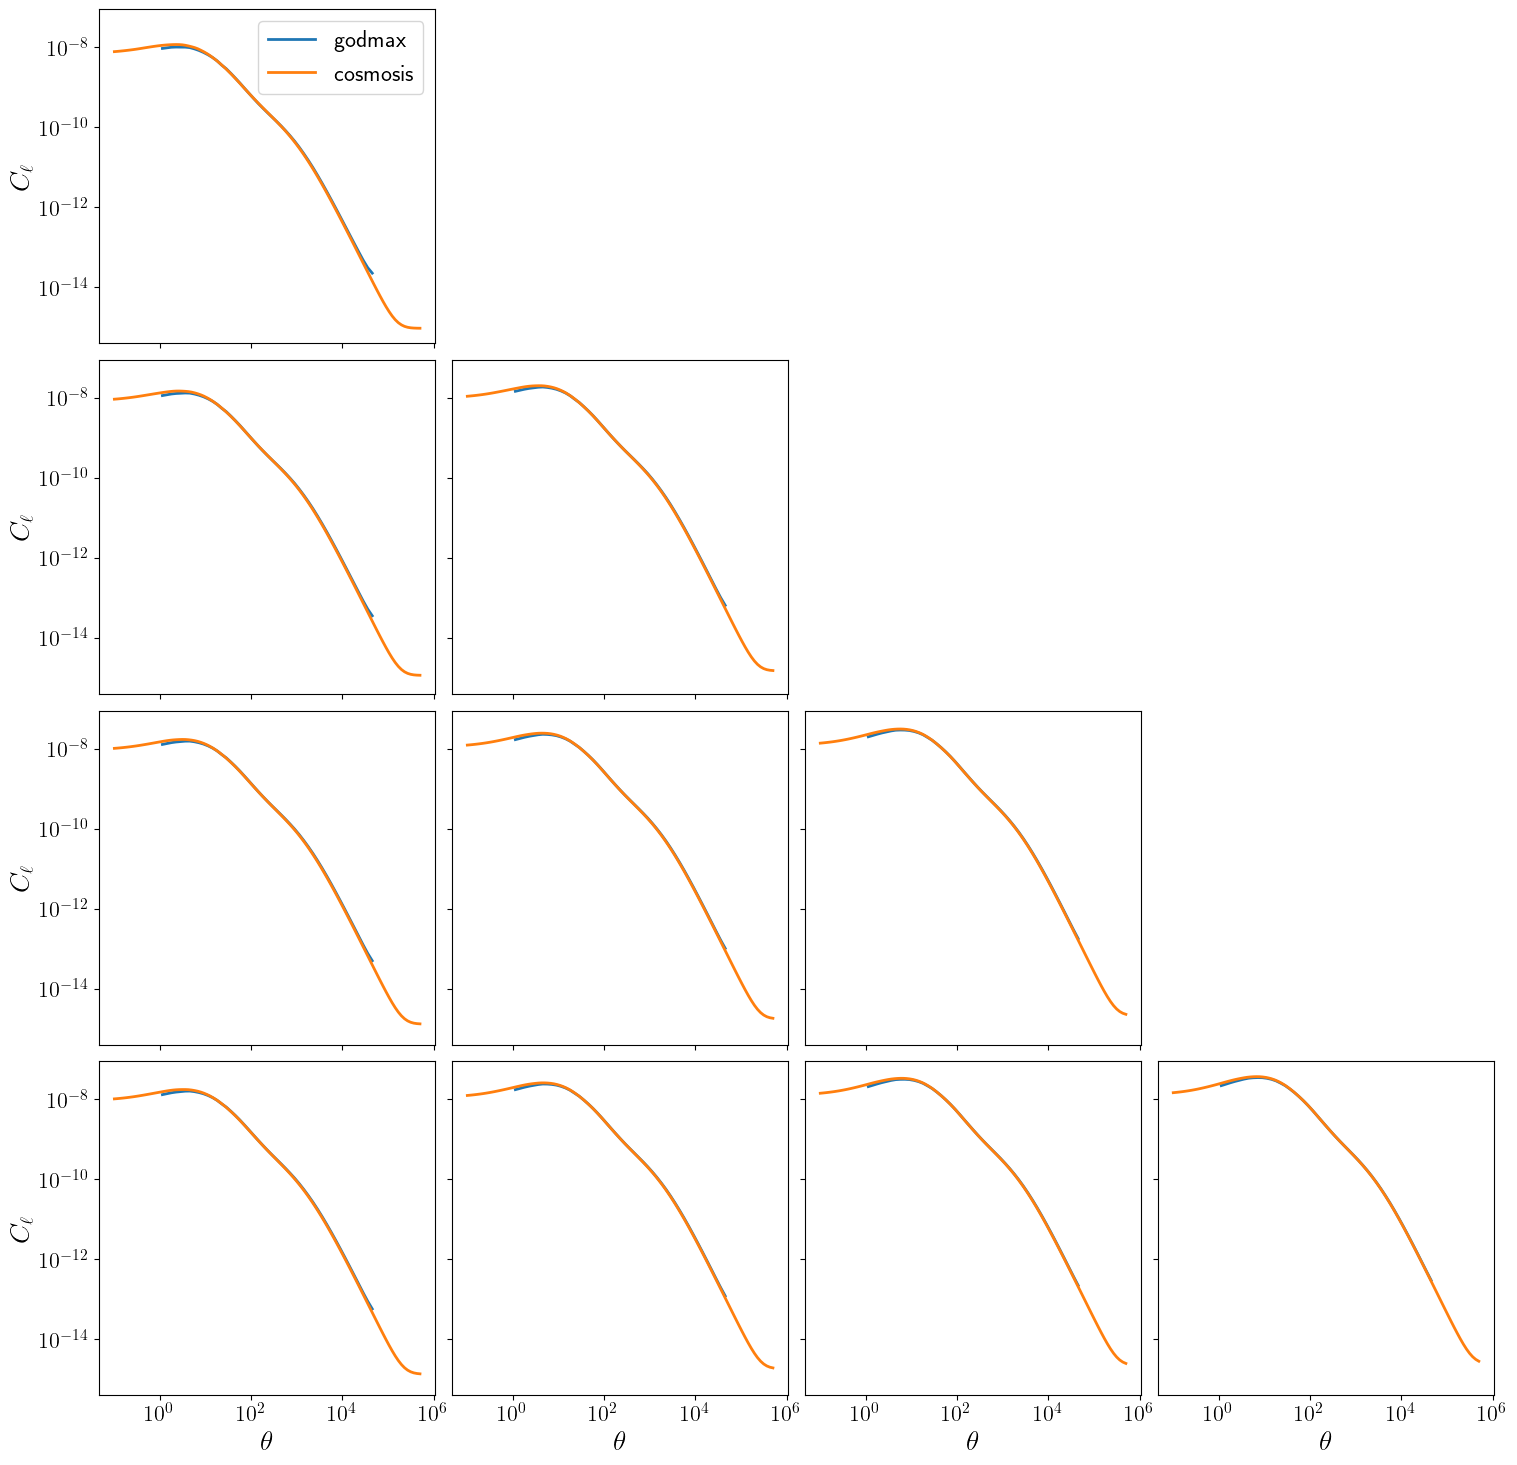

In [10]:
fig, axes = pl.subplots(4, 4, figsize=(18, 18), sharex=True, sharey=True)
# set spacing between suplots:
fig.subplots_adjust(hspace=0.05, wspace=0.05)
for ji1 in range(4):
    for ji2 in range(4):
        if ji1 <= ji2:
            ax = axes[ji2, ji1]
            ax.plot(Cls_test.ell_array, Cls_test.Cl_kappa_kappa_nfw_tot_mat[:,ji2,ji1], label='godmax', lw=2)
            ax.plot(results_fid_cs.block[('shear_cl', 'ell')], results_fid_cs.block[('shear_cl', f'bin_{ji2+1}_{ji1+1}')], label='cosmosis', lw=2)
            if ji1 == 0 and ji2 == 0:
                # ax.set_title('xim')
                ax.legend(fontsize=17)
            ax.set_xscale('log')
            ax.set_yscale('log')
            # ax.set_ylim(0, 9e-5)
            # ax.set_ylim(0, 4e-5)
            # ax.set_xlim(2.5, 250)
            if ji2 == 3:
                ax.set_xlabel(r'$\theta$', fontsize=20)
            if ji1 == 0:
                ax.set_ylabel(r'$C_{\ell}$', fontsize=20)
            ax.tick_params(axis='both', which='major', labelsize=16)
            ax.tick_params(axis='both', which='minor', labelsize=16)

            # if ji < 2:
                # ax.axvspan(0, 10, color='gray', alpha=0.2)
        else:
            # delete the subplot:
            fig.delaxes(axes[ji2, ji1])
    # ax.set_xlim(0, 20)
# fig.savefig('/mnt/home/spandey/ceph/GODMAX/results/ACTxDES/xip_dv.png', bbox_inches='tight', dpi=300)
pl.show()

 

In [11]:
# fig, axes = pl.subplots(4, 4, figsize=(18, 18), sharex=True, sharey=True)
# # set spacing between suplots:
# fig.subplots_adjust(hspace=0.05, wspace=0.05)
# for ji1 in range(4):
#     for ji2 in range(4):
#         if ji1 <= ji2:
#             ax = axes[ji2, ji1]
#             # ax.plot(xis_test.angles_data_array, xis_test.xip_out_mat[:,ji2,ji1], label='godmax', lw=2)
#             ax.plot(xis_test.angles_data_array, xis_test.xip_out_mat[:,ji1,ji2], label='godmax', lw=2)            
#             ax.plot(results_fid_cs.block[('shear_xi_plus', 'theta')]*(180*60/np.pi), results_fid_cs.block[('shear_xi_plus', f'bin_{ji2+1}_{ji1+1}')], label='cosmosis', lw=2)
#             indsel = np.where((bin1_xip_dv == ji1+1) & (bin2_xip_dv == ji2+1))[0]
#             ax.errorbar(theta_data, xip_dv[indsel], yerr=sig_xip_dv[indsel], fmt='o', label='DESxACT', color='k')
#             # ax.plot(xis_test.angles_data_array, xis_test.xip_out_mat[:,ji2,ji1]/results_fid_cs.block[('shear_xi_plus', f'bin_{ji2+1}_{ji1+1}')], label='godmax/cosmosis', lw=2)
#             # ax.fill_between(xis_test.angles_data_array, )
#             # ax.plot(results_fid_cs.block[('shear_xi_plus', 'theta')]*(180*60/np.pi), results_fid_cs.block[('shear_xi_plus', f'bin_{ji2+1}_{ji1+1}')], label='cosmosis', lw=2)
#             # ax.axhline(1.0, ls='--', color='k')

#             if ji1 == 0 and ji2 == 0:
#                 # ax.set_title('xim')
#                 ax.legend(fontsize=17)
#             ax.set_xscale('log')
#             ax.set_yscale('log')
#             # ax.set_ylim(0, 9e-5)
#             # ax.set_ylim(0, 4e-5)
#             # ax.set_xlim(2.5, 250)
#             if ji2 == 3:
#                 ax.set_xlabel(r'$\theta$', fontsize=20)
#             if ji1 == 0:
#                 ax.set_ylabel(r'$C_{\ell}$', fontsize=20)
#             ax.tick_params(axis='both', which='major', labelsize=16)
#             ax.tick_params(axis='both', which='minor', labelsize=16)

#             # if ji < 2:
#                 # ax.axvspan(0, 10, color='gray', alpha=0.2)
#         else:
#             # delete the subplot:
#             fig.delaxes(axes[ji2, ji1])
#     # ax.set_xlim(0, 20)
# # fig.savefig('/mnt/home/spandey/ceph/GODMAX/results/ACTxDES/xip_dv.png', bbox_inches='tight', dpi=300)
# pl.show()

 

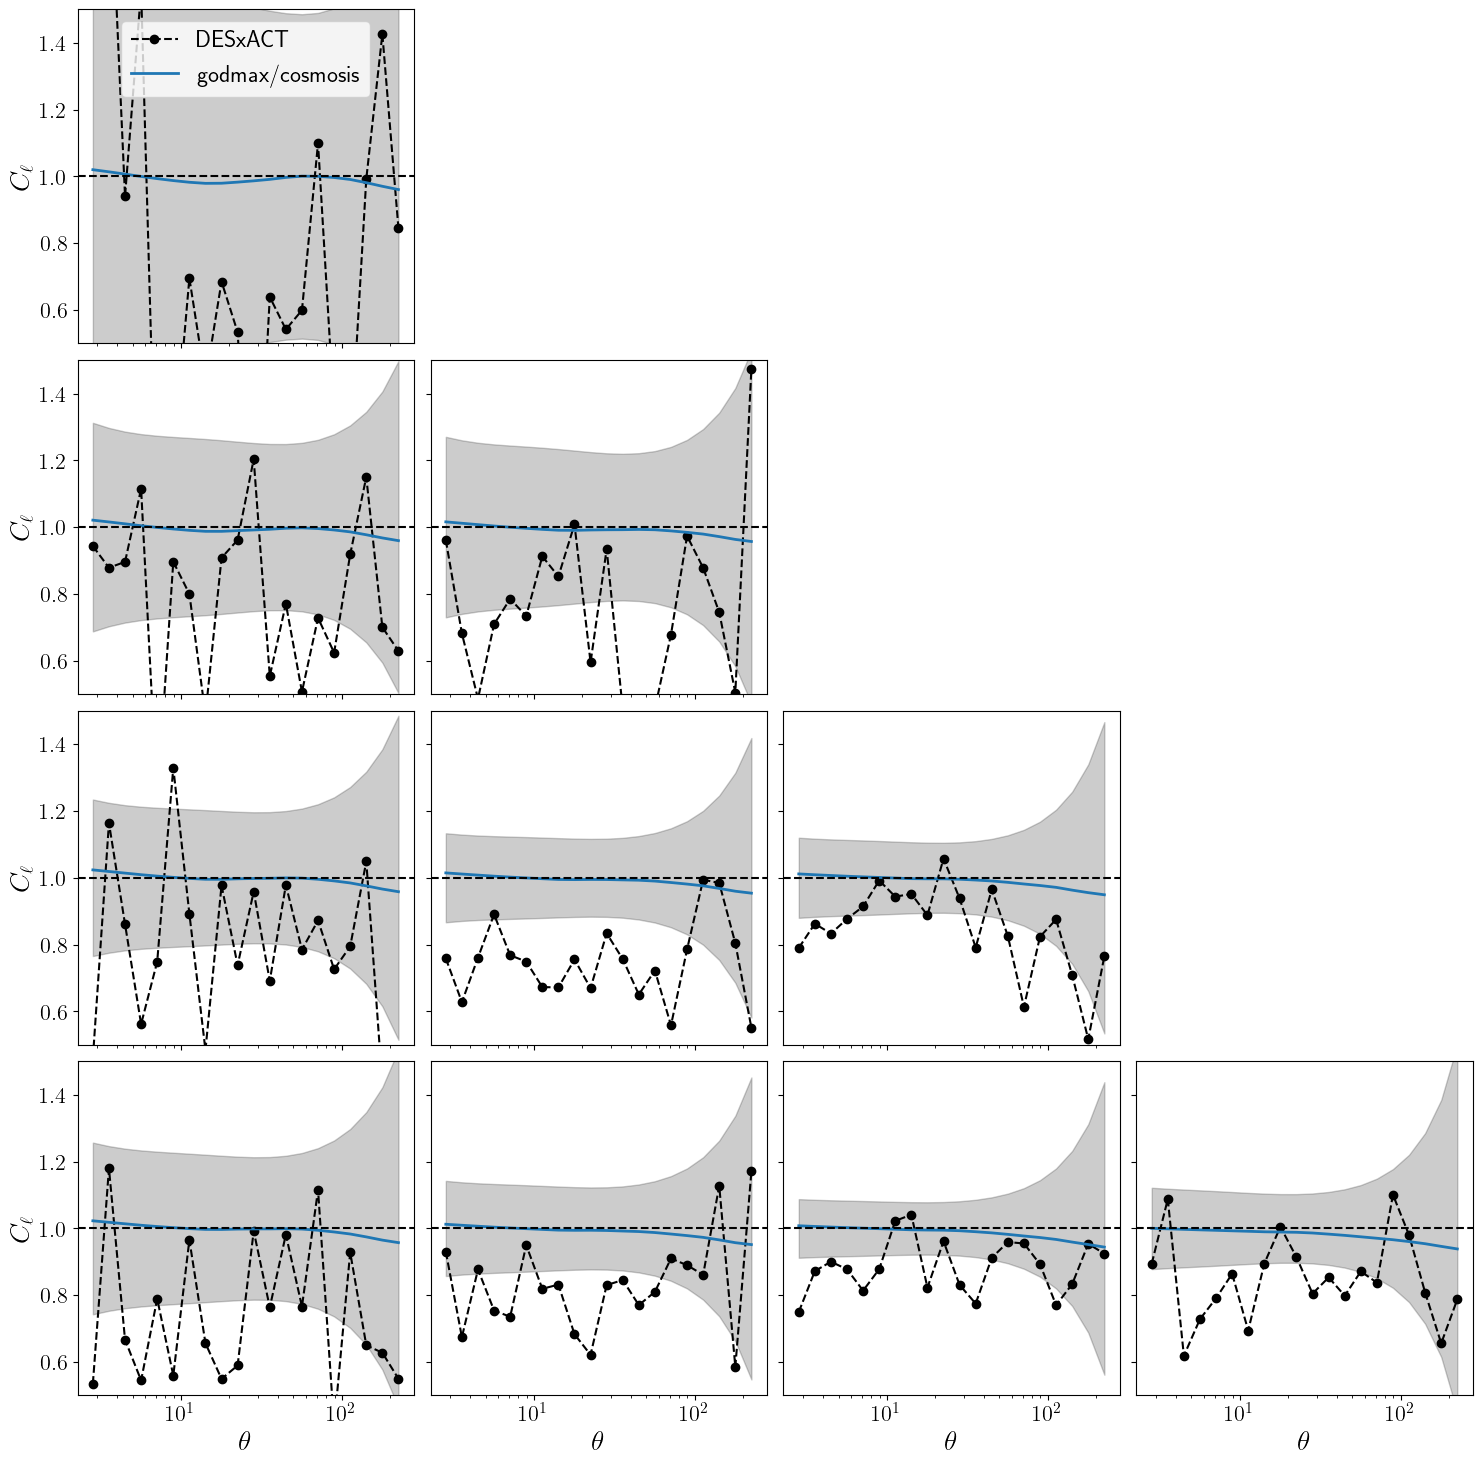

In [12]:
fig, axes = pl.subplots(4, 4, figsize=(18, 18), sharex=True, sharey=True)
# set spacing between suplots:
fig.subplots_adjust(hspace=0.05, wspace=0.05)
for ji1 in range(4):
    for ji2 in range(4):
        if ji1 <= ji2:
            ax = axes[ji2, ji1]
            # ax.plot(xis_test.angles_data_array, xis_test.xip_out_mat[:,ji2,ji1], label='godmax', lw=2)
            # ax.plot(xis_test.angles_data_array, xis_test.xip_out_mat[:,ji1,ji2], label='godmax', lw=2)            
            # ax.plot(results_fid_cs.block[('shear_xi_plus', 'theta')]*(180*60/np.pi), results_fid_cs.block[('shear_xi_plus', f'bin_{ji2+1}_{ji1+1}')], label='cosmosis', lw=2)
            indsel = np.where((bin1_xip_dv == ji1+1) & (bin2_xip_dv == ji2+1))[0]
            ax.plot(xis_test.angles_data_array, xip_dv[indsel]/results_fid_cs.block[('shear_xi_plus', f'bin_{ji2+1}_{ji1+1}')], marker='o', ls='--', label='DESxACT', color='k')
            ax.plot(xis_test.angles_data_array, xis_test.xip_out_mat[:,ji1,ji2]/results_fid_cs.block[('shear_xi_plus', f'bin_{ji2+1}_{ji1+1}')], label='godmax/cosmosis', lw=2)
            ax.fill_between(xis_test.angles_data_array, 1 - sig_xip_dv[indsel]/results_fid_cs.block[('shear_xi_plus', f'bin_{ji2+1}_{ji1+1}')], 1 + sig_xip_dv[indsel]/results_fid_cs.block[('shear_xi_plus', f'bin_{ji2+1}_{ji1+1}')], alpha=0.2, color='k')
            # ax.plot(results_fid_cs.block[('shear_xi_plus', 'theta')]*(180*60/np.pi), results_fid_cs.block[('shear_xi_plus', f'bin_{ji2+1}_{ji1+1}')], label='cosmosis', lw=2)
            ax.axhline(1.0, ls='--', color='k')

            if ji1 == 0 and ji2 == 0:
                # ax.set_title('xim')
                ax.legend(fontsize=17)
            ax.set_xscale('log')
            # ax.set_yscale('log')
            ax.set_ylim(0.5, 1.5)
            # ax.set_ylim(0, 4e-5)
            # ax.set_xlim(2.5, 250)
            if ji2 == 3:
                ax.set_xlabel(r'$\theta$', fontsize=20)
            if ji1 == 0:
                ax.set_ylabel(r'$C_{\ell}$', fontsize=20)
            ax.tick_params(axis='both', which='major', labelsize=16)
            ax.tick_params(axis='both', which='minor', labelsize=16)

            # if ji < 2:
                # ax.axvspan(0, 10, color='gray', alpha=0.2)
        else:
            # delete the subplot:
            fig.delaxes(axes[ji2, ji1])
    # ax.set_xlim(0, 20)
# fig.savefig('/mnt/home/spandey/ceph/GODMAX/results/ACTxDES/xip_dv.png', bbox_inches='tight', dpi=300)
pl.show()

 

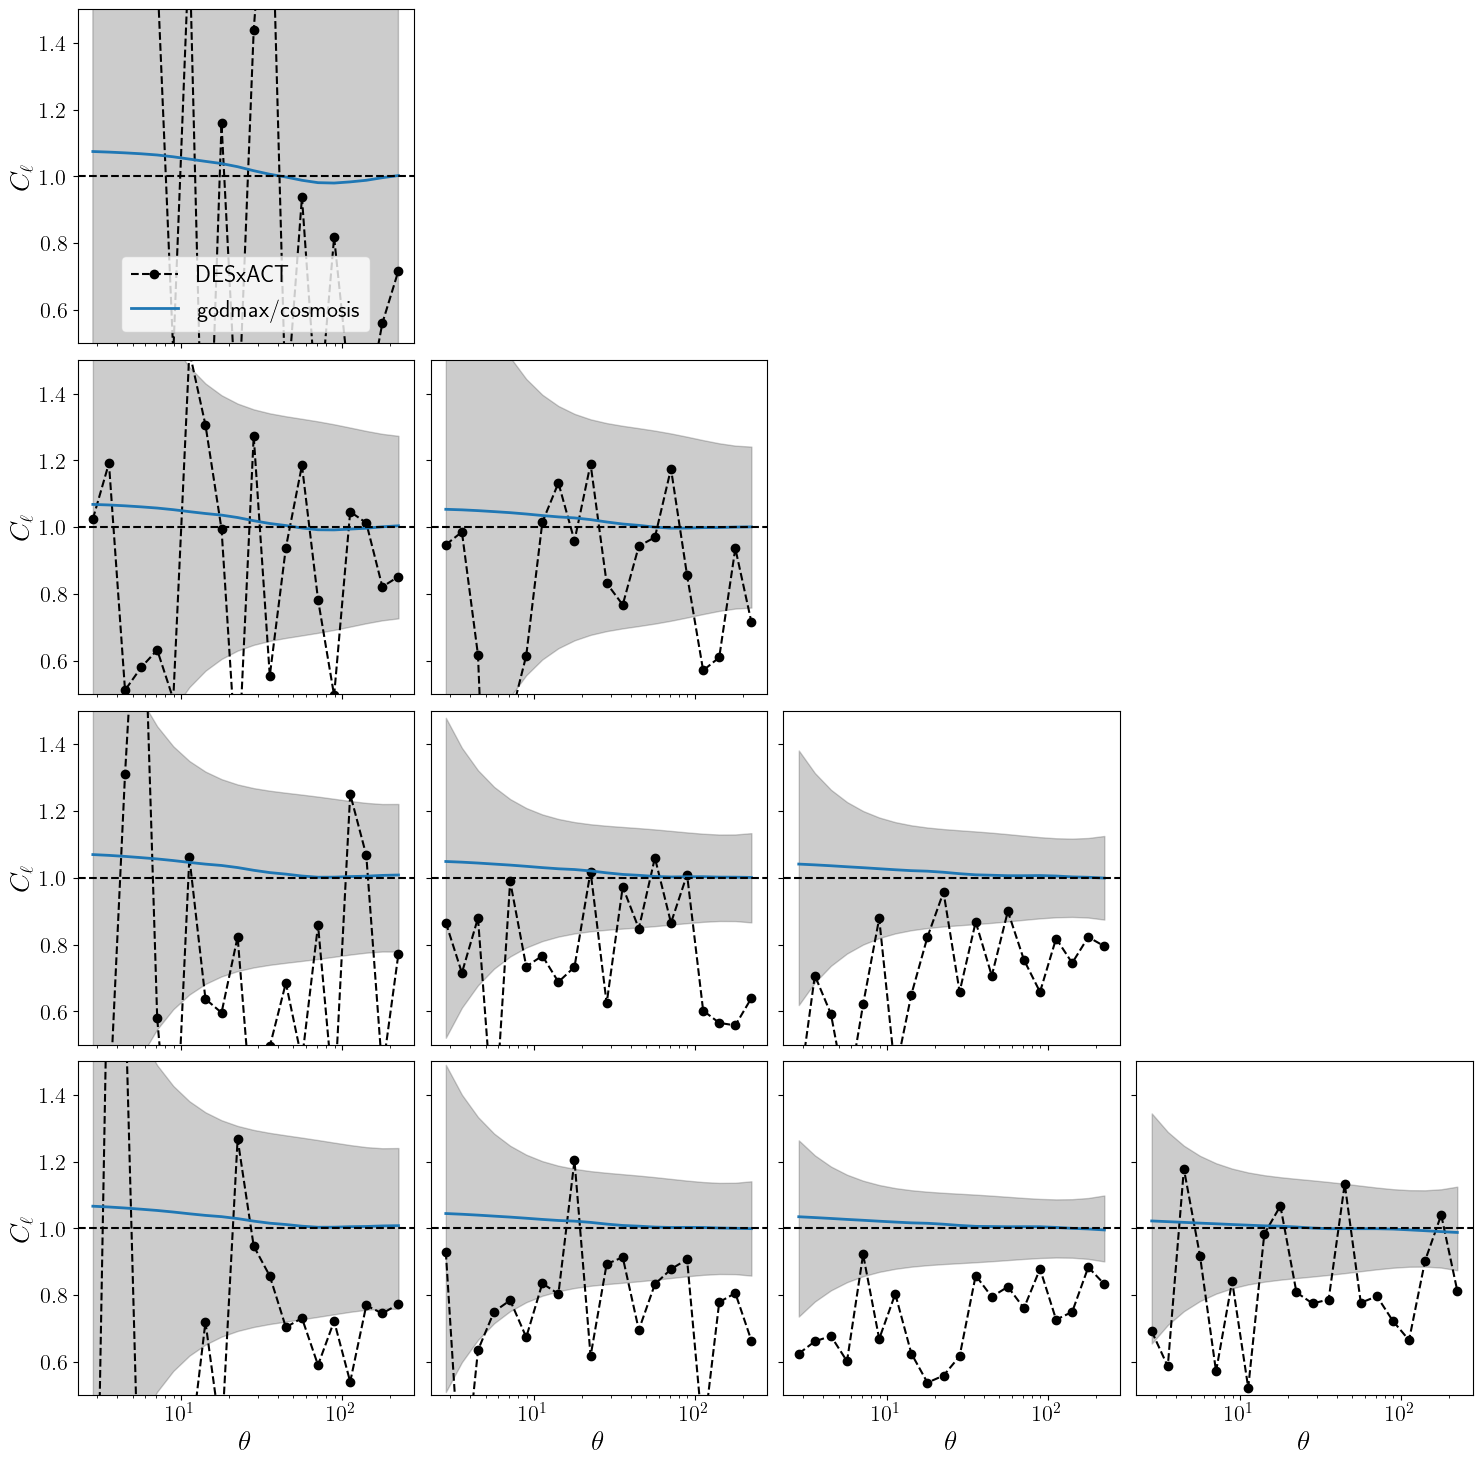

In [13]:
fig, axes = pl.subplots(4, 4, figsize=(18, 18), sharex=True, sharey=True)
# set spacing between suplots:
fig.subplots_adjust(hspace=0.05, wspace=0.05)
for ji1 in range(4):
    for ji2 in range(4):
        if ji1 <= ji2:
            ax = axes[ji2, ji1]
            # ax.plot(xis_test.angles_data_array, xis_test.xip_out_mat[:,ji2,ji1], label='godmax', lw=2)
            # ax.plot(xis_test.angles_data_array, xis_test.xip_out_mat[:,ji1,ji2], label='godmax', lw=2)            
            # ax.plot(results_fid_cs.block[('shear_xi_plus', 'theta')]*(180*60/np.pi), results_fid_cs.block[('shear_xi_plus', f'bin_{ji2+1}_{ji1+1}')], label='cosmosis', lw=2)
            indsel = np.where((bin1_xip_dv == ji1+1) & (bin2_xip_dv == ji2+1))[0]
            ax.plot(xis_test.angles_data_array, xim_dv[indsel]/results_fid_cs.block[('shear_xi_minus', f'bin_{ji2+1}_{ji1+1}')], marker='o', ls='--', label='DESxACT', color='k')
            ax.plot(xis_test.angles_data_array, xis_test.xim_out_mat[:,ji1,ji2]/results_fid_cs.block[('shear_xi_minus', f'bin_{ji2+1}_{ji1+1}')], label='godmax/cosmosis', lw=2)
            ax.fill_between(xis_test.angles_data_array, 1 - sig_xim_dv[indsel]/results_fid_cs.block[('shear_xi_minus', f'bin_{ji2+1}_{ji1+1}')], 1 + sig_xim_dv[indsel]/results_fid_cs.block[('shear_xi_minus', f'bin_{ji2+1}_{ji1+1}')], alpha=0.2, color='k')
            # ax.plot(results_fid_cs.block[('shear_xi_plus', 'theta')]*(180*60/np.pi), results_fid_cs.block[('shear_xi_plus', f'bin_{ji2+1}_{ji1+1}')], label='cosmosis', lw=2)
            ax.axhline(1.0, ls='--', color='k')

            if ji1 == 0 and ji2 == 0:
                # ax.set_title('xim')
                ax.legend(fontsize=17)
            ax.set_xscale('log')
            # ax.set_yscale('log')
            ax.set_ylim(0.5, 1.5)
            # ax.set_ylim(0, 4e-5)
            # ax.set_xlim(2.5, 250)
            if ji2 == 3:
                ax.set_xlabel(r'$\theta$', fontsize=20)
            if ji1 == 0:
                ax.set_ylabel(r'$C_{\ell}$', fontsize=20)
            ax.tick_params(axis='both', which='major', labelsize=16)
            ax.tick_params(axis='both', which='minor', labelsize=16)

            # if ji < 2:
                # ax.axvspan(0, 10, color='gray', alpha=0.2)
        else:
            # delete the subplot:
            fig.delaxes(axes[ji2, ji1])
    # ax.set_xlim(0, 20)
# fig.savefig('/mnt/home/spandey/ceph/GODMAX/results/ACTxDES/xip_dv.png', bbox_inches='tight', dpi=300)
pl.show()

 

In [14]:
get_corrfunc_BCMP_test = get_xi(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict)



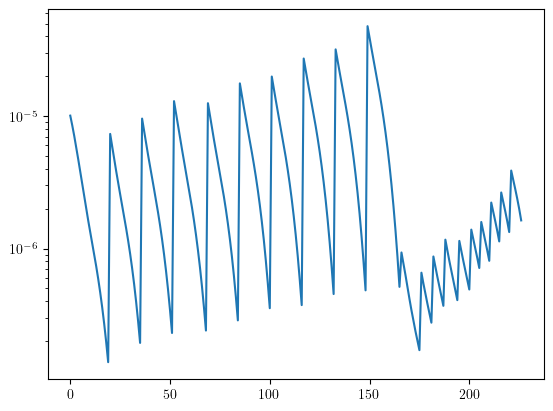

In [15]:
import configobj
probe = 'xip_xim'

if probe == 'xip_xim':
    cov_total = cov_total[80:, 80:]
    data_vec = data_vec[80:]
elif probe == 'gty':
    cov_total = cov_total[:80, :80]
    data_vec = data_vec[:80]

fname = abs_path_data + '/DESxACT/scale_cuts_xipm_y3_gty_fid.ini'
config = configobj.ConfigObj(fname)
sc_xipm = config['shear-shear']
sc_gty = config['shear-tsz']

df_cs = fits.open(abs_path_data + '/DESxACT/2pt_NG_final_2ptunblind_02_26_21_wnz_maglim_covupdate.fits') 
bin1_vals =  df_cs['xip'].data['BIN1'][::20]
bin2_vals =  df_cs['xip'].data['BIN2'][::20]
biny_vals = np.array([1,2,3,4])
ang_vals = df_cs['xip'].data['ANG'][0:20]

def process_indices(num, bin1_vals, bin2_vals, angle_ranges, offset, probe, angle_type, do_scalecuts):
    indices, indrm = [], []
    for js in range(num):
        binv, thetav = divmod(js, 20)
        bin1, bin2 = (bin1_vals[binv] - 1, bin2_vals[binv] - 1) if angle_type != 'gty' else (None, None)
        if do_scalecuts:
            sc_min, sc_max = map(float, angle_ranges[binv].split())
        else:
            sc_min, sc_max = 1e-3, 999.0
        if sc_min < ang_vals[thetav] < sc_max:
            indices.append([int(thetav), int(bin1), int(bin2)] if bin1 is not None else [int(thetav), int(binv)])
        elif probe in [angle_type, 'all']:
            indrm.append(int(offset + js))
    return jnp.array(indices, dtype=jnp.int32), jnp.array(indrm, dtype=jnp.int32)

# Process gty indices
sc_ranges_gty = [sc_gty[f'angle_range_gty_{biny}_0'] for biny in biny_vals]
index_gty, indrm_gty = process_indices(80, None, None, sc_ranges_gty, 0, probe, 'gty', True)
len_ind_gty = len(index_gty)
# Process xip indices
sc_ranges_xip = [sc_xipm[f'angle_range_xip_{bin1}_{bin2}'] for bin1, bin2 in zip(bin1_vals, bin2_vals)]
offset_xip = 80 if probe in ['gty', 'all'] else 0
index_xip, indrm_xip = process_indices(200, bin1_vals, bin2_vals, sc_ranges_xip, offset_xip, probe, 'xip_xim', True)
len_ind_xip = len(index_xip)
# Process xim indices
sc_ranges_xim = [sc_xipm[f'angle_range_xim_{bin1}_{bin2}'] for bin1, bin2 in zip(bin1_vals, bin2_vals)]
offset_xim = 280 if probe in ['gty', 'all'] else 200
index_xim, indrm_xim = process_indices(200, bin1_vals, bin2_vals, sc_ranges_xim, offset_xim, probe, 'xip_xim', True)
len_ind_xim = len(index_xim)

indrm = jnp.concatenate([indrm_gty, indrm_xip, indrm_xim], dtype=jnp.int32)
print('removing indices: ', indrm)

if len(indrm) > 0:
    data_vec = jnp.delete(data_vec, indrm)
    cov_total = jnp.delete(cov_total, indrm, axis=0)
    cov_total = jnp.delete(cov_total, indrm, axis=1)
P_total = jnp.linalg.inv(cov_total)


def get_gty_from_index(index):
    index_val = index_gty[index]
    return get_corrfunc_BCMP_test.gty_out_mat[index_val[0], index_val[1]]

def get_xip_from_index(index):
    index_val = index_xip[index]
    return get_corrfunc_BCMP_test.xip_out_mat[index_val[0], index_val[1], index_val[2]]

def get_xim_from_index(index):
    index_val = index_xim[index]
    return get_corrfunc_BCMP_test.xim_out_mat[index_val[0], index_val[1], index_val[2]]

gty_val = vmap(get_gty_from_index)(jnp.arange(len_ind_gty))
xip_val = vmap(get_xip_from_index)(jnp.arange(len_ind_xip))
xim_val = vmap(get_xim_from_index)(jnp.arange(len_ind_xim))

if probe == 'xip_xim':
    mu = jnp.concatenate([xip_val, xim_val])
elif probe == 'gty':
    mu = gty_val
else:
    mu = jnp.concatenate([gty_val, xip_val, xim_val])

pl.figure()
pl.plot(mu)
pl.yscale('log')



In [16]:
xip_val.shape, xim_val.shape


((166,), (61,))

In [17]:
mu.shape, data_vec.shape, cov_total.shape



((227,), (227,), (227, 227))

In [18]:
# len(mu)
diff = mu - data_vec
chi2 = diff.T @ jnp.linalg.inv(cov_total) @ diff
# print(chi2)


In [19]:
chi2



Array(276.60429082, dtype=float64)

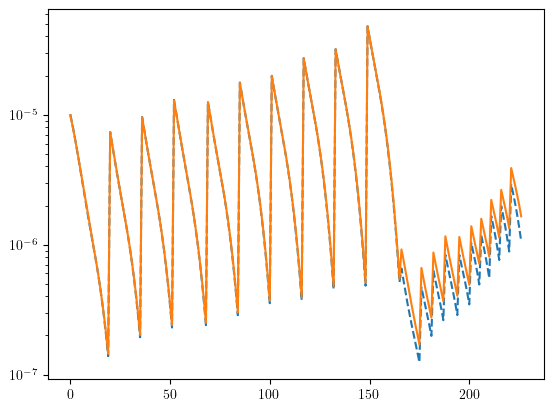

In [31]:
pl.figure()
pl.plot(mu, ls='--')
pl.plot(results_fid_cs.block['data_vector', '2pt_theory'])
pl.yscale('log')


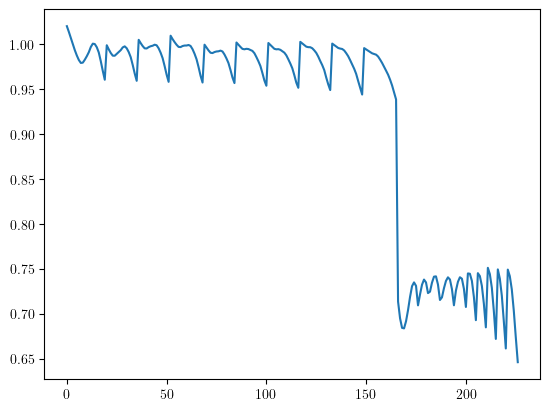

In [28]:
# chi2
pl.figure()
pl.plot(mu/results_fid_cs.block['data_vector', '2pt_theory'])




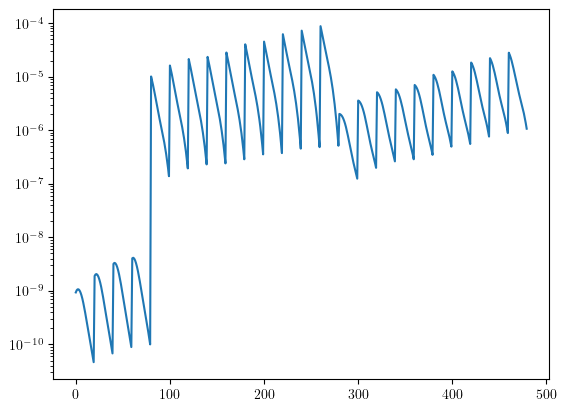

In [90]:
import configobj
if probe == 'xip_xim':
    cov_total = cov_total[80:, 80:]
    data_vec = data_vec[80:]
elif probe == 'gty':
    cov_total = cov_total[:80, :80]
    data_vec = data_vec[:80]

fname = abs_path_data + '/DESxACT/scale_cuts_xipm_y3_gty_fid.ini'
config = configobj.ConfigObj(fname)
sc_xipm = config['shear-shear']
sc_gty = config['shear-tsz']

df_cs = fits.open(abs_path_data + '/DESxACT/2pt_NG_final_2ptunblind_02_26_21_wnz_maglim_covupdate.fits') 
bin1_vals =  df_cs['xip'].data['BIN1'][::20]
bin2_vals =  df_cs['xip'].data['BIN2'][::20]
biny_vals = np.array([1,2,3,4])
ang_vals = df_cs['xip'].data['ANG'][0:20]

def process_indices(num, bin1_vals, bin2_vals, angle_ranges, offset, probe, angle_type, do_scalecuts):
    indices, indrm = [], []
    for js in range(num):
        binv, thetav = divmod(js, 20)
        bin1, bin2 = (bin1_vals[binv] - 1, bin2_vals[binv] - 1) if angle_type != 'gty' else (None, None)
        if do_scalecuts:
            sc_min, sc_max = map(float, angle_ranges[binv].split())
        else:
            sc_min, sc_max = 1e-3, 999.0
        if sc_min < ang_vals[thetav] < sc_max:
            indices.append([int(thetav), int(bin1), int(bin2)] if bin1 is not None else [int(thetav), int(binv)])
        elif probe in [angle_type, 'all']:
            indrm.append(int(offset + js))
    return jnp.array(indices, dtype=jnp.int32), jnp.array(indrm, dtype=jnp.int32)

# Process gty indices
sc_ranges_gty = [sc_gty[f'angle_range_gty_{biny}_0'] for biny in biny_vals]
index_gty, indrm_gty = process_indices(80, None, None, sc_ranges_gty, 0, probe, 'gty', False)
len_ind_gty = len(index_gty)
# Process xip indices
sc_ranges_xip = [sc_xipm[f'angle_range_xip_{bin1}_{bin2}'] for bin1, bin2 in zip(bin1_vals, bin2_vals)]
offset_xip = 80 if probe in ['gty', 'all'] else 0
index_xip, indrm_xip = process_indices(200, bin1_vals, bin2_vals, sc_ranges_xip, offset_xip, probe, 'xip_xim', False)
len_ind_xip = len(index_xip)
# Process xim indices
sc_ranges_xim = [sc_xipm[f'angle_range_xim_{bin1}_{bin2}'] for bin1, bin2 in zip(bin1_vals, bin2_vals)]
offset_xim = 280 if probe in ['gty', 'all'] else 200
index_xim, indrm_xim = process_indices(200, bin1_vals, bin2_vals, sc_ranges_xim, offset_xim, probe, 'xip_xim', False)
len_ind_xim = len(index_xim)

def get_gty_from_index(index):
    index_val = index_gty[index]
    return get_corrfunc_BCMP_test.gty_out_mat[index_val[0], index_val[1]]

def get_xip_from_index(index):
    index_val = index_xip[index]
    return get_corrfunc_BCMP_test.xip_out_mat[index_val[0], index_val[1], index_val[2]]

def get_xim_from_index(index):
    index_val = index_xim[index]
    return get_corrfunc_BCMP_test.xim_out_mat[index_val[0], index_val[1], index_val[2]]

gty_val = vmap(get_gty_from_index)(jnp.arange(len_ind_gty))
xip_val = vmap(get_xip_from_index)(jnp.arange(len_ind_xip))
xim_val = vmap(get_xim_from_index)(jnp.arange(len_ind_xim))

if probe == 'xip_xim':
    mu = jnp.concatenate([xip_val, xim_val])
elif probe == 'gty':
    mu = gty_val
else:
    mu = jnp.concatenate([gty_val, xip_val, xim_val])

pl.figure()
pl.plot(mu)
pl.yscale('log')



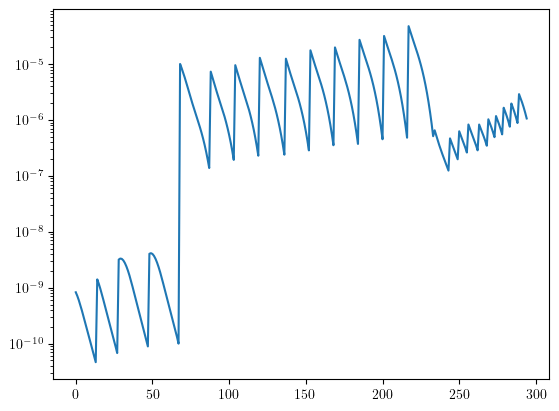

In [13]:
# fig, axes = pl.subplots(1, 5, figsize=(18, 5), sharex=True, sharey=True)
# # set spacing between suplots:
# fig.subplots_adjust(hspace=0.05, wspace=0.05)
# for ji1 in range(5):
#     # for ji2 in range(5):
#         # if ji1 <= ji2:
#     ax = axes[ji1]
#     ax.plot(get_power_test.ell_array, get_power_test.Cl_gal_gal_tot_mat[ji1, ji1,:], label='godmax', lw=2)
#     ax.plot(results_fid_cs.block[('galaxy_cl', 'ell')], results_fid_cs.block[('galaxy_cl', f'bin_{ji1+1}_{ji1+1}')], label='cosmosis', lw=2)
#     if ji1 == 0:
#         # ax.set_title('xim')
#         ax.legend(fontsize=17)
#     ax.set_xscale('log')
#     ax.set_yscale('log')
#     # ax.set_ylim(0, 9e-5)
#     # ax.set_ylim(0, 4e-5)
#     ax.set_xlim(100, 10000)
#     if ji2 == 3:
#         ax.set_xlabel(r'$\theta$', fontsize=20)
#     if ji1 == 0:
#         ax.set_ylabel(r'$C_{\ell}$', fontsize=20)
#     ax.tick_params(axis='both', which='major', labelsize=16)
#     ax.tick_params(axis='both', which='minor', labelsize=16)

#     # if ji < 2:
#         # ax.axvspan(0, 10, color='gray', alpha=0.2)
#         # else:
#         #     # delete the subplot:
#         #     fig.delaxes(axes[ji2, ji1])
#     # ax.set_xlim(0, 20)
# # fig.savefig('/mnt/home/spandey/ceph/GODMAX/results/ACTxDES/xip_dv.png', bbox_inches='tight', dpi=300)
# pl.show()

 

In [14]:
# fig, axes = pl.subplots(5, 4, figsize=(18, 22), sharex=True, sharey=True)
# # set spacing between suplots:
# fig.subplots_adjust(hspace=0.05, wspace=0.05)
# for ji1 in range(5):
#     for ji2 in range(4):
#         # if ji1 <= ji2:
#         ax = axes[ji1, ji2]
#         ax.plot(get_power_test.ell_array, get_power_test.Cl_gal_kappa_tot_mat[ji1, ji2,:], label='godmax', lw=2)
#         ax.plot(results_fid_cs.block[('galaxy_shear_cl', 'ell')], results_fid_cs.block[('galaxy_shear_cl', f'bin_{ji1+1}_{ji2+1}')], label='cosmosis', lw=2)
#         if ji1 == 0 and ji2 == 0:
#             # ax.set_title('xim')
#             ax.legend(fontsize=17)
#         ax.set_xscale('log')
#         ax.set_yscale('log')
#         # ax.set_ylim(0, 9e-5)
#         # ax.set_ylim(0, 4e-5)
#         # ax.set_xlim(2.5, 250)
#         if ji1 == 3:
#             ax.set_xlabel(r'$\theta$', fontsize=20)
#         if ji2 == 0:
#             ax.set_ylabel(r'$C_{\ell}$', fontsize=20)
#         ax.tick_params(axis='both', which='major', labelsize=16)
#         ax.tick_params(axis='both', which='minor', labelsize=16)
#         ax.set_xlim(20, 10000)
#             # if ji < 2:
#                 # ax.axvspan(0, 10, color='gray', alpha=0.2)
#         # else:
#         #     # delete the subplot:
#         #     fig.delaxes(axes[ji2, ji1])
#     # ax.set_xlim(0, 20)
# # fig.savefig('/mnt/home/spandey/ceph/GODMAX/results/ACTxDES/xip_dv.png', bbox_inches='tight', dpi=300)
# pl.show()

 

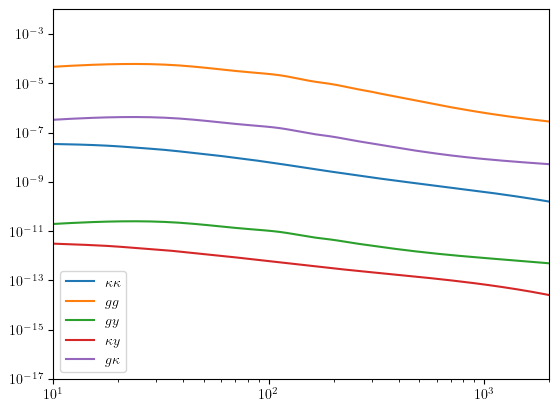

In [36]:
# fac = (get_power_test.ell_array)*(get_power_test.ell_array+1)/(2*np.pi) 
fac = 1.
pl.figure()
pl.plot(get_power_test.ell_array, fac*get_power_test.Cl_kappa_kappa_tot_mat[3,3,:], label=r'$\kappa \kappa$')
# pl.plot(get_power_test.ell_array, fac*get_power_test.Cl_gal_gal_tot_mat[0,0,:], label=r'$gg$')
# pl.plot(get_power_test.ell_array, fac*get_power_test.Cl_gal_gal_tot_mat[1,1,:], label=r'$gg$')
pl.plot(get_power_test.ell_array, fac*get_power_test.Cl_gal_gal_tot_mat[2,2,:], label=r'$gg$')
pl.plot(get_power_test.ell_array, fac*get_power_test.Cl_gal_y_tot_mat[2,:], label=r'$gy$')
pl.plot(get_power_test.ell_array, fac*get_power_test.Cl_kappa_y_tot_mat[3,:], label=r'$\kappa y$')
pl.plot(get_power_test.ell_array, fac*get_power_test.Cl_gal_kappa_tot_mat[2,3,:], label=r'$g\kappa$')
pl.xscale('log')
pl.yscale('log')
pl.ylim(1e-17, 1e-2)
pl.xlim(10, 2e3)
pl.legend()


In [237]:
from setup_power_spectra import setup_power_BCMP

setup_power_BCMP_test = setup_power_BCMP(sim_params_dict, halo_params_dict, analysis_dict, num_points_trapz_int=64, verbose_time=True)





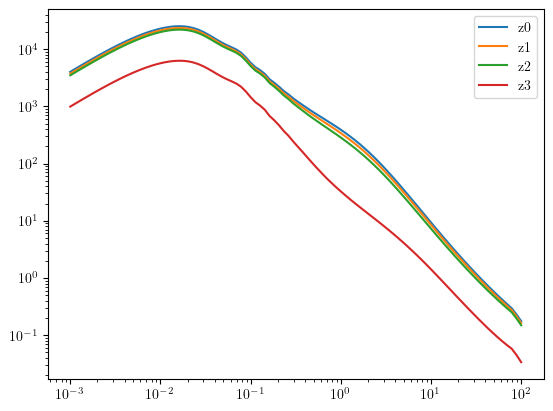

In [236]:
# setup_power_BCMP_test.Pmm_tot_kz_mat.shape
pl.figure()
# pl.plot(results_fid_cs.block['growth_parameters', 'z'], results_fid_cs.block['growth_parameters', 'd_z'], label='cosmosis')
pl.plot(setup_power_BCMP_test.k, setup_power_BCMP_test.Pmm_tot_kz_mat[:,0], label='z0')
pl.plot(setup_power_BCMP_test.k, setup_power_BCMP_test.Pmm_tot_kz_mat[:,1], label='z1')
pl.plot(setup_power_BCMP_test.k, setup_power_BCMP_test.Pmm_tot_kz_mat[:,2], label='z2')
pl.plot(setup_power_BCMP_test.k, setup_power_BCMP_test.Pmm_tot_kz_mat[:,-1], label='z3')

pl.legend()
pl.xscale('log')
pl.yscale('log')
# pl.plot()


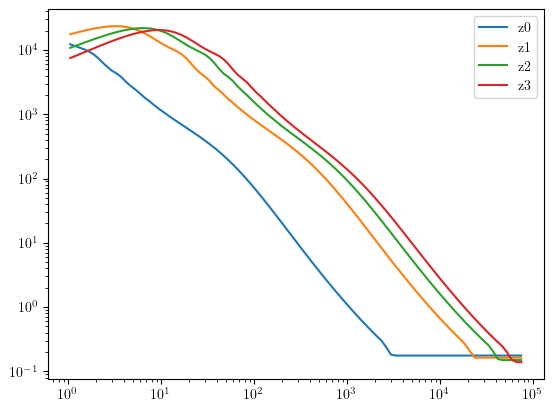

In [238]:
# .shape
pl.figure()
# pl.plot(results_fid_cs.block['growth_parameters', 'z'], results_fid_cs.block['growth_parameters', 'd_z'], label='cosmosis')
pl.plot(setup_power_BCMP_test.ell_array, setup_power_BCMP_test.Pkmm_lz_mat[:,0], label='z0')
pl.plot(setup_power_BCMP_test.ell_array, setup_power_BCMP_test.Pkmm_lz_mat[:,1], label='z1')
pl.plot(setup_power_BCMP_test.ell_array, setup_power_BCMP_test.Pkmm_lz_mat[:,2], label='z2')
pl.plot(setup_power_BCMP_test.ell_array, setup_power_BCMP_test.Pkmm_lz_mat[:,3], label='z3')

pl.legend()
pl.xscale('log')
pl.yscale('log')
# pl.plot()



[]

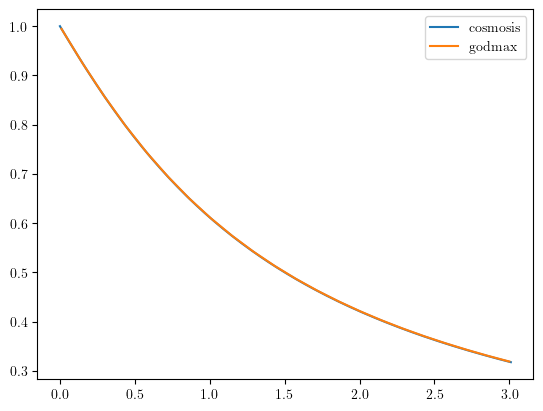

In [44]:
pl.figure()
pl.plot(results_fid_cs.block['growth_parameters', 'z'], results_fid_cs.block['growth_parameters', 'd_z'], label='cosmosis')
pl.plot(setup_power_BCMP_test.z_array, setup_power_BCMP_test.growth_array, label='godmax')
pl.legend()
pl.plot()



[]

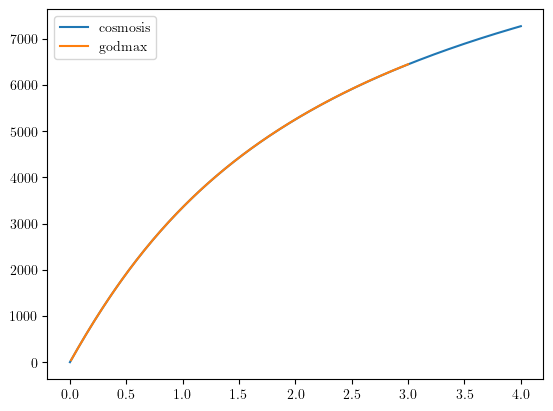

In [132]:
pl.figure()
pl.plot(results_fid_cs.block['distances', 'z'], results_fid_cs.block['distances', 'd_m'], label='cosmosis')
pl.plot(setup_power_BCMP_test.z_array, setup_power_BCMP_test.chi_array/0.69, label='godmax')
pl.legend()
pl.plot()
# pl.yscale('log')



[]

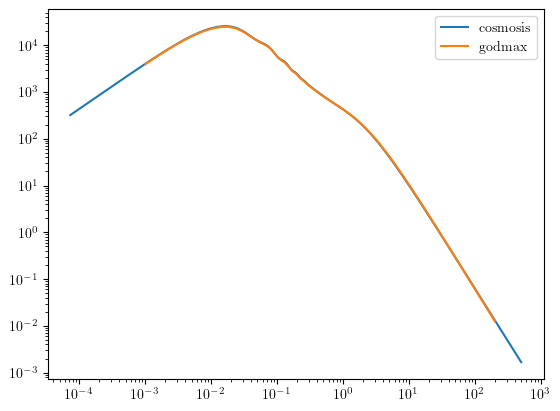

In [137]:
zplot = 0.0

pl.figure()
zarray = np.array(results_fid_cs.block[('matter_power_nl', 'z')])
indp = np.argmin(np.abs(zarray - zplot))
print(indp)
pl.plot(results_fid_cs.block[('matter_power_nl', 'k_h')], results_fid_cs.block[('matter_power_nl', 'p_k')][indp,:], label='cosmosis')

indp = np.argmin(np.abs(setup_power_BCMP_test.z_array - zplot))
print(indp)
pl.plot(setup_power_BCMP_test.k, setup_power_BCMP_test.Pmm_tot_kz_mat[:,indp], label='godmax')
pl.legend()
pl.xscale('log')
pl.yscale('log')
pl.plot()



In [257]:
import copy
from tqdm import tqdm
# from get_corr_func_jit import get_corrfunc_BCMP
from get_power_spectra import get_power_BCMP
# sim_params_dict['nu_theta_ej_M'] = -0.1
get_power_BCMP_test = get_power_BCMP(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, verbose_time=False)




In [258]:
# jnp.all(jnp.isfinite(get_power_BCMP_test.Pkmm_lz_mat))


In [259]:
# get_power_BCMP_test.Pkmm_lz_mat


In [260]:
# get_power_BCMP_test.Wk_gravonly_mat.shape
# jnp.all(jnp.isfinite(get_power_BCMP_test.Cl_kappa_kappa_tot_mat))



In [261]:
# get_power_BCMP_test.nla_mat
# get_power_BCMP_test.Delta_z_bias_array
# get_power_BCMP_test.Cl_kappa_kappa_tot_mat



[]

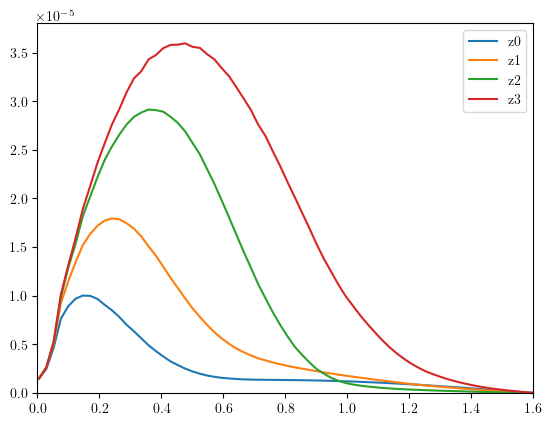

In [262]:
# zplot = 1.0

pl.figure()
# zarray = np.array(results_fid_cs.block[('matter_power_nl', 'z')])
# indp = np.argmin(np.abs(zarray - zplot))
# print(indp)
# pl.plot(results_fid_cs.block[('matter_power_nl', 'k_h')], results_fid_cs.block[('matter_power_nl', 'p_k')][indp,:], label='cosmosis')

# indp = np.argmin(np.abs(setup_power_BCMP_test.z_array - zplot))
# print(indp)
pl.plot(get_power_BCMP_test.z_array, get_power_BCMP_test.Wk_gravonly_mat[0,:], label='z0')
pl.plot(get_power_BCMP_test.z_array, get_power_BCMP_test.Wk_gravonly_mat[1,:], label='z1')
pl.plot(get_power_BCMP_test.z_array, get_power_BCMP_test.Wk_gravonly_mat[2,:], label='z2')
pl.plot(get_power_BCMP_test.z_array, get_power_BCMP_test.Wk_gravonly_mat[3,:], label='z3')
pl.legend()
# pl.xscale('log')
# pl.yscale('log')
pl.xlim(0,1.6)
pl.ylim(0,3.8e-5)
pl.plot()



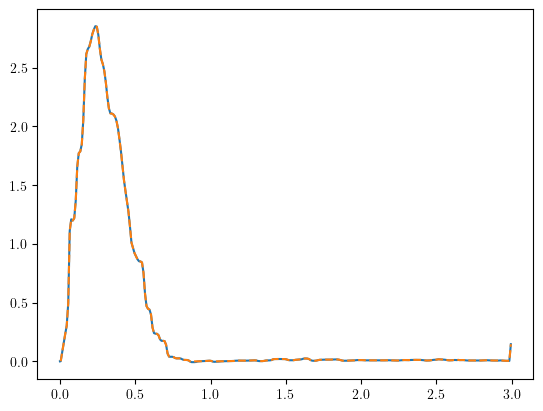

In [263]:
pl.figure()
pl.plot(results_fid_cs.block[('nz_source', 'z')], results_fid_cs.block[('nz_source', 'bin_1')])
pl.plot(get_power_BCMP_test.z_array_nz, get_power_BCMP_test.pzs_inp_mat[0,:], label='z0', ls='--')
# pl.plot(results_fid_cs.block[('nz_source', 'z')], results_fid_cs.block[('nz_source', 'bin_2')])
# pl.plot(results_fid_cs.block[('nz_source', 'z')], results_fid_cs.block[('nz_source', 'bin_3')])
# pl.plot(results_fid_cs.block[('nz_source', 'z')], results_fid_cs.block[('nz_source', 'bin_4')])



In [6]:
import pickle as pk
df = pk.load(open('/projects/bdne/spandey3/GODMAX/notebooks/kk_limber_integral.pkl','rb'))
list(df[0].keys())



['chi_vals',
 'kernel1_vals',
 'kernel2_vals',
 'pk_vals',
 'ells',
 'c_ells',
 'c_ell_errs']

In [62]:
ind = 0
chi_vals = df[ind]['chi_vals']
kernel1_vals = df[ind]['kernel1_vals']
kernel2_vals = df[ind]['kernel2_vals']
ells = df[ind]['ells']
pk_vals = df[ind]['pk_vals']
Cells = df[ind]['c_ells']
# K_vals = (ells[:,np.newaxis] + 0.5)/chi_vals
# CHI_VALS = (chi_vals[:, np.newaxis]).T * np.ones((ells.shape[0], chi_vals.shape[0]))
pkmmlz_cs_interp2d = interp.interp2d(np.log(chi_vals), np.log(ells), np.log(pk_vals), kind='linear')
Cell_interp1d = interp.interp1d(np.log(ells), np.log(Cells), kind='linear', fill_value='extrapolate')



/tmp/ipykernel_1099536/1827355577.py:10: DeprecationWarning: `interp2d` is deprecated in SciPy 1.10 and will be removed in SciPy 1.14.0.

For legacy code, nearly bug-for-bug compatible replacements are
`RectBivariateSpline` on regular grids, and `bisplrep`/`bisplev` for
scattered 2D data.

In new code, for regular grids use `RegularGridInterpolator` instead.
For scattered data, prefer `LinearNDInterpolator` or
`CloughTocher2DInterpolator`.

For more details see
`https://scipy.github.io/devdocs/notebooks/interp_transition_guide.html`

  pkmmlz_cs_interp2d = interp.interp2d(np.log(chi_vals), np.log(ells), np.log(pk_vals), kind='linear')


In [67]:
# ells

array([1.00000000e-01, 1.16860130e-01, 1.36562899e-01, 1.59587581e-01,
       1.86494254e-01, 2.17937427e-01, 2.54681959e-01, 2.97621668e-01,
       3.47801067e-01, 4.06440777e-01, 4.74967219e-01, 5.55047308e-01,
       6.48629003e-01, 7.57988694e-01, 8.85786570e-01, 1.03513133e+00,
       1.20965582e+00, 1.41360536e+00, 1.65194105e+00, 1.93046046e+00,
       2.25593859e+00, 2.63629276e+00, 3.08077514e+00, 3.60019782e+00,
       4.20719584e+00, 4.91653451e+00, 5.74546860e+00, 6.71416206e+00,
       7.84617848e+00, 9.16905434e+00, 1.07149688e+01, 1.25215264e+01,
       1.46326720e+01, 1.70997595e+01, 1.99828011e+01, 2.33519272e+01,
       2.72890924e+01, 3.18900688e+01, 3.72667757e+01, 4.35500024e+01,
       5.08925893e+01, 5.94731458e+01, 6.95003953e+01, 8.12182520e+01,
       9.49117546e+01, 1.10913999e+02, 1.29614243e+02, 1.51467373e+02,
       1.77004968e+02, 2.06848235e+02, 2.41723116e+02, 2.82477947e+02,
       3.30104095e+02, 3.85760073e+02, 4.50799721e+02, 5.26805138e+02,
      

In [63]:
# pk_vals.shape, len(ells)
pk_mmlz_eval = np.exp(pkmmlz_cs_interp2d(np.log(get_power_BCMP_test.chi_array), np.log(get_power_BCMP_test.ell_array)))
Cell_eval = np.exp(Cell_interp1d(np.log(get_power_BCMP_test.ell_array)))


/tmp/ipykernel_1099536/3652393812.py:2: DeprecationWarning: `interp2d` is deprecated in SciPy 1.10 and will be removed in SciPy 1.14.0.

For legacy code, nearly bug-for-bug compatible replacements are
`RectBivariateSpline` on regular grids, and `bisplrep`/`bisplev` for
scattered 2D data.

In new code, for regular grids use `RegularGridInterpolator` instead.
For scattered data, prefer `LinearNDInterpolator` or
`CloughTocher2DInterpolator`.

For more details see
`https://scipy.github.io/devdocs/notebooks/interp_transition_guide.html`

  pk_mmlz_eval = np.exp(pkmmlz_cs_interp2d(np.log(get_power_BCMP_test.chi_array), np.log(get_power_BCMP_test.ell_array)))


In [64]:
# pk_mmlz_eval.shape
# len(get_power_BCMP_test.ell_array)
get_power_BCMP_test.ell_array


Array([1.06100923e-01, 1.19047193e-01, 1.33573148e-01, 1.49871537e-01,
       1.68158630e-01, 1.88677087e-01, 2.11699173e-01, 2.37530379e-01,
       2.66513469e-01, 2.99033031e-01, 3.35520579e-01, 3.76460281e-01,
       4.22395383e-01, 4.73935415e-01, 5.31764282e-01, 5.96649338e-01,
       6.69451568e-01, 7.51137014e-01, 8.42789592e-01, 9.45625476e-01,
       1.06100923e+00, 1.19047194e+00, 1.33573149e+00, 1.49871538e+00,
       1.68158632e+00, 1.88677088e+00, 2.11699175e+00, 2.37530381e+00,
       2.66513471e+00, 2.99033033e+00, 3.35520581e+00, 3.76460284e+00,
       4.22395386e+00, 4.73935418e+00, 5.31764286e+00, 5.96649342e+00,
       6.69451573e+00, 7.51137019e+00, 8.42789598e+00, 9.45625482e+00,
       1.06100924e+01, 1.19047195e+01, 1.33573150e+01, 1.49871539e+01,
       1.68158633e+01, 1.88677089e+01, 2.11699176e+01, 2.37530382e+01,
       2.66513473e+01, 2.99033035e+01, 3.35520584e+01, 3.76460287e+01,
       4.22395389e+01, 4.73935422e+01, 5.31764290e+01, 5.96649346e+01,
      

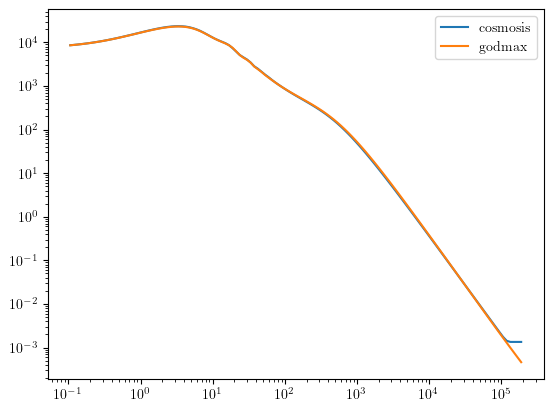

In [65]:
pl.figure()
pl.plot(get_power_BCMP_test.ell_array, pk_mmlz_eval[:,3], label='cosmosis')
pl.plot(get_power_BCMP_test.ell_array, get_power_BCMP_test.Pkmm_lz_mat[:,3], label='godmax')
pl.yscale('log')
pl.xscale('log')
pl.legend()




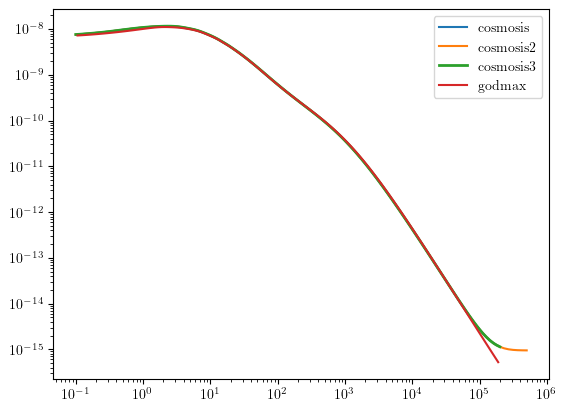

In [73]:
c_kms = 299792.4580
omega_m = Om
shear_scaling = 1.5 * (100.0*100.0)/(c_kms*c_kms) * omega_m

pl.figure()
pl.plot(get_power_BCMP_test.ell_array, (shear_scaling**2)*Cell_eval, label='cosmosis')
pl.plot(ells, (shear_scaling**2)*Cells, label='cosmosis2')
pl.plot(results_fid_cs.block[('shear_cl', 'ell')], results_fid_cs.block[('shear_cl', f'bin_{1}_{1}')], label='cosmosis3', lw=2)
pl.plot(get_power_BCMP_test.ell_array, get_power_BCMP_test.Cl_kappa_kappa_tot_mat[0,0,:], label='godmax')
pl.plot(get_power_BCMP_test.ell_array, get_power_BCMP_test.Cl_kappa_kappa_tot[0,0,:], label='godmax')

pl.yscale('log')
pl.xscale('log')
pl.legend()






In [46]:
get_power_BCMP_test.Cl_kappa_kappa_tot_mat.shape


(4, 4, 126)

In [21]:
pl.figure()
pl.plot(chi_vals, 5e-8*kernel1_vals)
pl.plot(get_power_BCMP_test.chi_array, get_power_BCMP_test.Wk_gravonly_mat[0,:], label='z0')
pl.yscale('log')
pl.xscale('log')


((126, 128), (126,))